# Лабораторная работа №2. Временные ряды погоды
Студент: Ларьков Андрей Александрович
Группа: М8О-103БВ-25

В данном ноутбуке последовательно обрабатывается Excel-файл с погодой и строится прогноз температуры на неделю вперед.


## 1. Загрузка данных

Сначала смотрим, какие листы есть в Excel-файле, но данные читаем только из трех нужных листов - был проведен анализ листов на количество колонок, их содержимое. Так как процесс загрузки очень трудоемкий, в финальный пайплайн вошло только открытие нужных листов. Это важно, потому что в файле есть служебные и пустые листы, которые не относятся к временному ряду.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb
from IPython.display import Markdown, display
from openpyxl import load_workbook
from scipy.signal import periodogram
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

DATA_PATH = "have_fun.xlsx"
SHEETS = [
    "Ëèñò1",
    "Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû",
    "Ëèñò3_ñìåøàííûå_òèïû",
]

TARGET = "temperature_2m"
HORIZON = 14
RANDOM_STATE = 42
N_TRIALS = 10

NUMERIC_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]
BASE_COLS = NUMERIC_COLS + ["ds", "city"]

wb = load_workbook(DATA_PATH, read_only=True, data_only=True)
sheet_info = pd.DataFrame({
    "Лист": wb.sheetnames,
    "Статус": [wb[sheet].sheet_state for sheet in wb.sheetnames],
    "Используем": [sheet in SHEETS for sheet in wb.sheetnames],
})
wb.close()

df1 = pd.read_excel(DATA_PATH, sheet_name=SHEETS[0], engine="openpyxl")
df2 = pd.read_excel(DATA_PATH, sheet_name=SHEETS[1], engine="openpyxl")
df3 = pd.read_excel(DATA_PATH, sheet_name=SHEETS[2], engine="openpyxl")

sheet_sizes = pd.DataFrame({
    "Лист": SHEETS,
    "Строк": [len(df1), len(df2), len(df3)],
    "Столбцов": [df1.shape[1], df2.shape[1], df3.shape[1]],
})

display(sheet_info)
display(sheet_sizes)


/Users/andrew/Documents/python/Frameworks data analys/lab2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Лист,Статус,Используем
0,Ëèñò1,visible,True
1,Лист1,visible,False
2,ÌÀÈ,visible,False
3,ýòî,visible,False
4,ÿ,visible,False
5,!,visible,False
6,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,hidden,True
7,Ëèñò3_ñìåøàííûå_òèïû,hidden,True


,Лист,Строк,Столбцов
0,Ëèñò1,125124,10
1,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,125169,25
2,Ëèñò3_ñìåøàííûå_òèïû,122736,10


## 2. Очистка и унификация данных

Теперь приводим три листа к одному виду: числовые признаки делаем числами, дату делаем датой, а названия городов исправляем. Для временного ряда важно, чтобы у каждой строки были правильные время и город.


In [2]:
def fix_text(value):
    if not isinstance(value, str):
        return value
    try:
        return value.encode("latin-1").decode("cp1251")
    except Exception:
        return value


dataframes = []
for df in [df1, df2, df3]:
    df = df[BASE_COLS].copy()

    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
    df["city"] = df["city"].apply(fix_text)
    dataframes.append(df)

# Объединяем три рабочих листа
df_all = pd.concat(dataframes, ignore_index=True)
rows_before = len(df_all)
missing_before_grid = df_all[BASE_COLS].isna().sum()

# Убираем строки без даты или города
df_all = df_all.dropna(subset=["ds", "city"]).copy()

df_all["city"] = (
    df_all["city"]
    .astype("string")
    .str.strip()
    .str.replace("ё", "е", regex=False)
    .str.lower()
    .str.capitalize()
)

city_mapping = {
    "Благавещенск": "Благовещенск",
    "Благовещенс": "Благовещенск",
    "Благовещенскк": "Благовещенск",
    "Геленджи": "Геленджик",
    "Геленджикк": "Геленджик",
    "Мосва": "Москва",
    "Санкт-петербург": "Санкт-Петербург",
    "Соч": "Сочи",
    "Счи": "Сочи",
    "Сычи": "Сочи",
}
df_all["city"] = df_all["city"].replace(city_mapping)

# Округляем время до часа и объединяем дубли по среднему значению
df_all["ds"] = df_all["ds"].dt.round("h")
df_all = (
    df_all
    .groupby(["city", "ds"], as_index=False)[NUMERIC_COLS]
    .mean()
    .sort_values(["city", "ds"])
)

# Для каждого города строим одинаковую часовую сетку
full_range = pd.date_range(df_all["ds"].min(), df_all["ds"].max(), freq="h")
city_parts = []

for city in sorted(df_all["city"].unique()):
    city_df = df_all[df_all["city"] == city].set_index("ds").sort_index()
    city_df = city_df.reindex(full_range)
    city_df["city"] = city
    city_parts.append(city_df)

df_hourly = pd.concat(city_parts).rename_axis("ds").reset_index()
df_hourly = df_hourly[["ds", "city"] + NUMERIC_COLS]

summary = pd.DataFrame({
    "Критерий": [
        "строк в исходных 3 листах",
        "строк после объединения и округления",
        "строк после полной часовой сетки",
        "количество городов",
        "начало ряда",
        "конец ряда",
    ],
    "Значение": [
        rows_before,
        len(df_all),
        len(df_hourly),
        df_hourly["city"].nunique(),
        df_hourly["ds"].min(),
        df_hourly["ds"].max(),
    ],
})

missing_after_grid = df_hourly[NUMERIC_COLS].isna().sum()
missing_table = pd.DataFrame({
    "До сетки": missing_before_grid,
    "После сетки": missing_after_grid,
}).fillna(0).astype(int)

display(summary)
display(df_hourly["city"].value_counts().sort_index().to_frame("Строк"))
display(missing_table)


,Показатель,Значение
0,строк в исходных 3 листах,373029
1,строк после объединения и округления,368090
2,строк после полной часовой сетки,368208
3,количество городов,6
4,начало ряда,2019-01-01 00:00:00
5,конец ряда,2025-12-31 23:00:00


,Строк
city,
Благовещенск,61368
Геленджик,61368
Москва,61368
Находка,61368
Санкт-Петербург,61368
Сочи,61368


,До сетки,После сетки
city,2487,0
ds,2486,0
precipitation,6157,3799
rain,2484,118
relative_humidity_2m,2459,123
snowfall,2484,118
surface_pressure,2485,118
temperature_2m,6778,4407
weathercode,4326,1959
wind_speed_10m,5573,3182


## 3. Обработка выбросов и пропусков

Погодные признаки всегда имеют логичные ограничения(влажность не бывает больше 100%, скорость ветра и давление тоже не должны быть невозможными). После удаления таких значений пропуски заполняем линейной интерполяцией внутри каждого города.


In [3]:
df_weather = df_hourly.copy()
missing_before = df_weather[NUMERIC_COLS].isna().sum()

# Физические лимиты
limits = {
    "temperature_2m": (-50, 45),
    "relative_humidity_2m": (0, 100),
    "precipitation": (0, 200),
    "rain": (0, 200),
    "snowfall": (0, 100),
    "weathercode": (0, 99),
    "wind_speed_10m": (0, 40),
    "surface_pressure": (900, 1100),
}

physical_outliers = {}
for col, borders in limits.items():
    low, high = borders
    bad_mask = (df_weather[col] < low) | (df_weather[col] > high)
    physical_outliers[col] = int(bad_mask.sum())
    df_weather.loc[bad_mask, col] = np.nan

missing_after_limits = df_weather[NUMERIC_COLS].isna().sum()

# Локальные резкие шипы убираем через rolling median
spike_rules = [
    ("temperature_2m", 5, 10),
    ("surface_pressure", 5, 15),
    ("wind_speed_10m", 5, 12),
]

local_spikes = {}
for col, window, threshold in spike_rules:
    rolling_median = df_weather.groupby("city")[col].transform(
        lambda x: x.rolling(window=window, center=True, min_periods=1).median()
    )
    spike_mask = (df_weather[col] - rolling_median).abs() > threshold
    local_spikes[col] = int(spike_mask.sum())
    df_weather.loc[spike_mask, col] = np.nan

missing_after_spikes = df_weather[NUMERIC_COLS].isna().sum()

for col in NUMERIC_COLS:
    df_weather[col] = df_weather.groupby("city")[col].transform(
        lambda x: x.interpolate(method="linear").ffill().bfill()
    )

df_weather["weathercode"] = df_weather["weathercode"].round().clip(0, 99)
missing_after_fill = df_weather[NUMERIC_COLS].isna().sum()

quality_table = pd.DataFrame({
    "Пропуски до обработки": missing_before,
    "Физические выбросы": pd.Series(physical_outliers),
    "Локальные шипы": pd.Series(local_spikes),
    "Пропуски после лимитов": missing_after_limits,
    "Пропуски после шипов": missing_after_spikes,
    "Пропуски после заполнения": missing_after_fill,
}).fillna(0).astype(int)

display(quality_table)


,Пропуски до обработки,Физические выбросы,Локальные шипы,Пропуски после лимитов,Пропуски после шипов,Пропуски после заполнения
precipitation,3799,613,0,4412,4412,0
rain,118,0,0,118,118,0
relative_humidity_2m,123,0,0,123,123,0
snowfall,118,0,0,118,118,0
surface_pressure,118,310,249,428,677,0
temperature_2m,4407,627,599,5034,5633,0
weathercode,1959,0,0,1959,1959,0
wind_speed_10m,3182,1073,59,4255,4314,0


## 4. Анализ временного ряда (EDA)

Перед обучением моделей нужно посмотреть, как температура меняется во времени, определить сезонность и циклы.


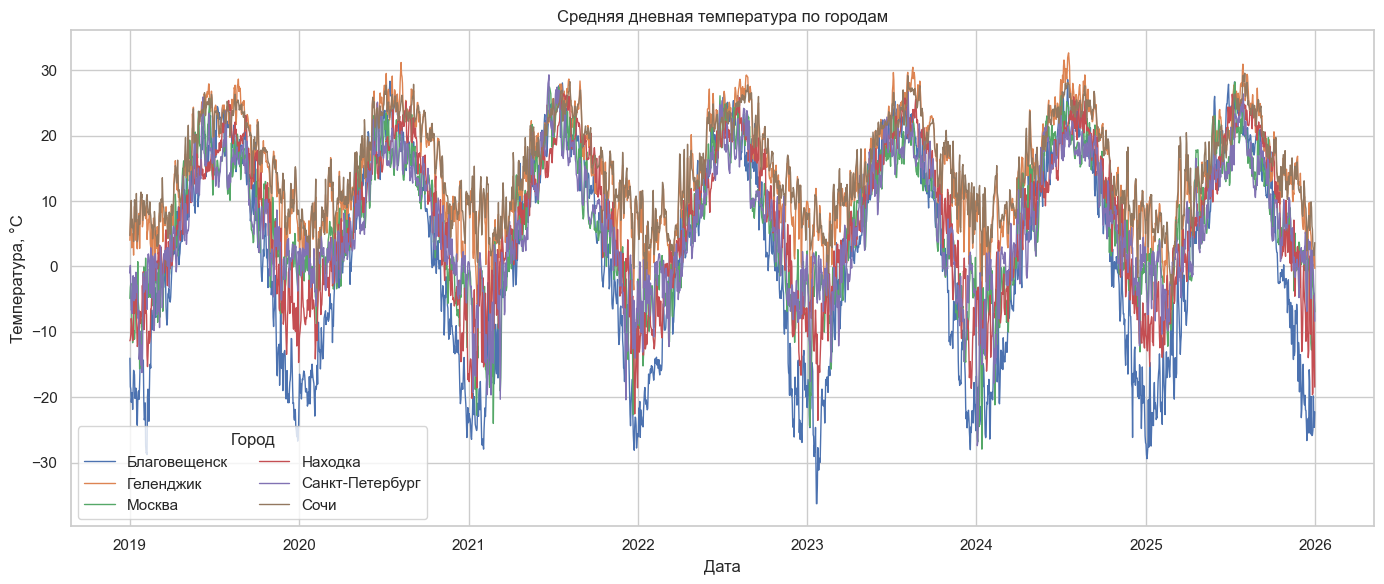

In [4]:
daily_temp = (
    df_weather
    .groupby("city")
    .resample("D", on="ds")[TARGET]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_temp, x="ds", y=TARGET, hue="city", linewidth=1)
plt.title("Средняя дневная температура по городам")
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.legend(title="Город", ncol=2)
plt.tight_layout()
plt.show()


### Тест Дики-Фуллера

Тест Дики-Фуллера помогает понять, насколько ряд стабилен по среднему уровню. Если `p-value < 0.05`, то ряд можно считать стационарным.


In [5]:
adf_rows = []

for city in sorted(df_weather["city"].unique()):
    city_series = df_weather[df_weather["city"] == city][TARGET].dropna()
    adf_result = adfuller(city_series, maxlag=24, regression="c", autolag=None)
    p_value = adf_result[1]

    if p_value < 0.05:
        conclusion = "скорее стационарен"
    else:
        conclusion = "скорее нестационарен"

    adf_rows.append({
        "Город": city,
        "ADF statistic": adf_result[0],
        "p-value": p_value,
        "Вывод": conclusion,
    })

adf_table = pd.DataFrame(adf_rows)
display(adf_table)


,Город,ADF statistic,p-value,Вывод
0,Благовещенск,-5.545387,1.665400e-06,скорее стационарен
1,Геленджик,-9.681010,1.204675e-16,скорее стационарен
2,Москва,-9.235242,1.637174e-15,скорее стационарен
3,Находка,-7.205991,2.299549e-10,скорее стационарен
4,Санкт-Петербург,-9.324259,9.705932e-16,скорее стационарен
5,Сочи,-8.335312,3.284482e-13,скорее стационарен


### Декомпозиция и спектральный анализ

Декомпозиция делит ряд на тренд, сезонность и остаток. Спектральный анализ показывает, какие циклы сильнее всего повторяются в данных(например суточный цикл температуры)


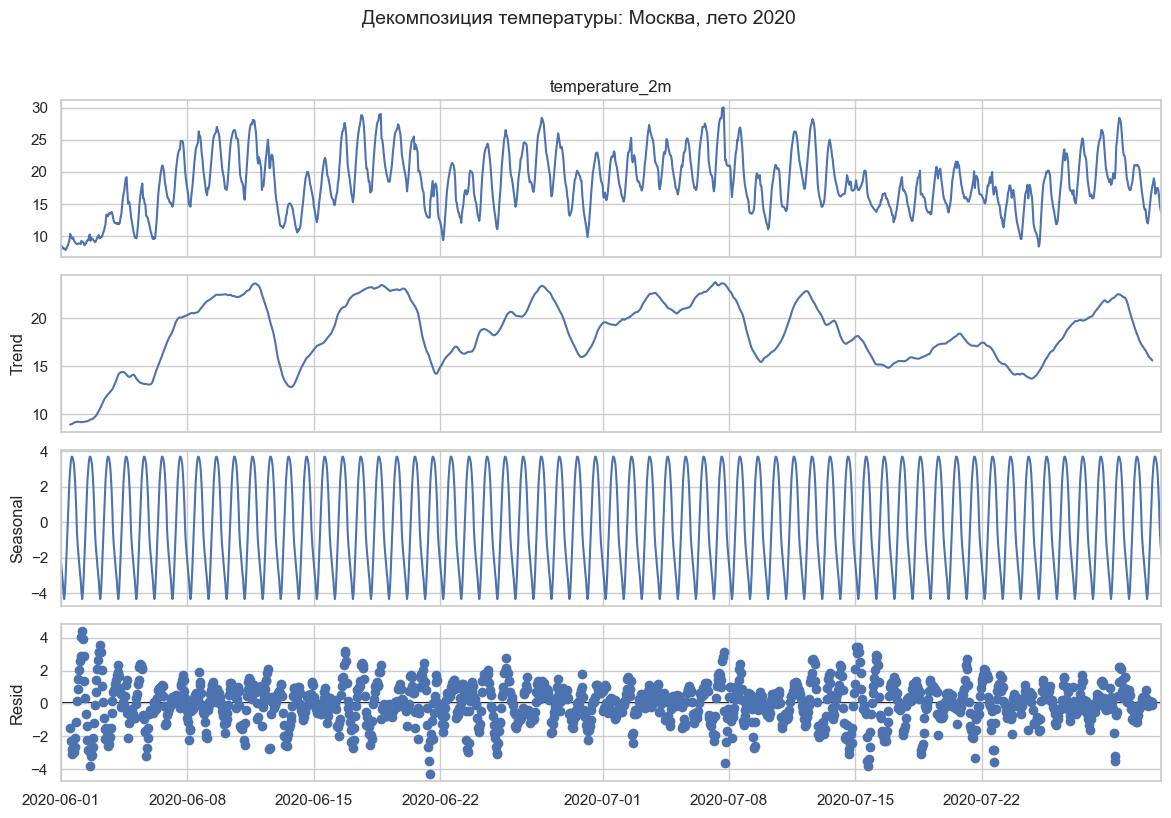

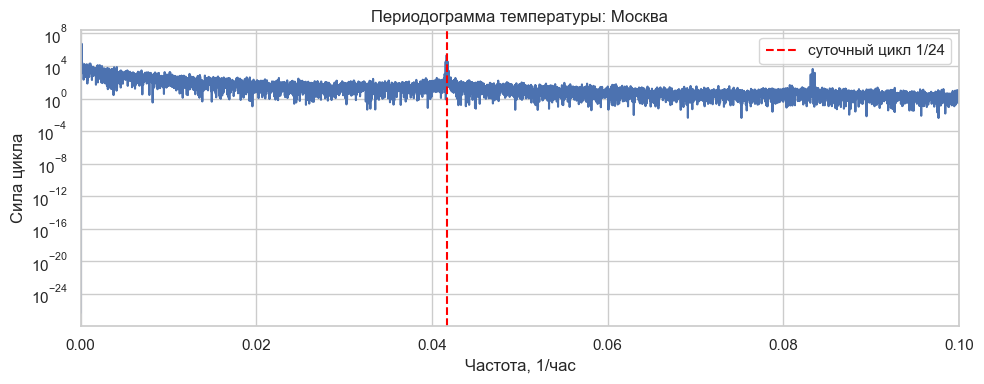

In [6]:
city_for_eda = "Москва"
moscow_temp = (
    df_weather[df_weather["city"] == city_for_eda]
    .set_index("ds")[TARGET]
    .asfreq("h")
)

summer_temp = moscow_temp.loc["2020-06-01":"2020-07-31"].dropna()
decompose_result = seasonal_decompose(summer_temp, model="additive", period=24)

fig = decompose_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Декомпозиция температуры: Москва, лето 2020", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

freqs, power = periodogram(moscow_temp.dropna(), fs=1)

plt.figure(figsize=(10, 4))
plt.semilogy(freqs, power)
plt.axvline(1 / 24, color="red", linestyle="--", label="суточный цикл 1/24")
plt.xlim(0, 0.1)
plt.title("Периодограмма температуры: Москва")
plt.xlabel("Частота, 1/час")
plt.ylabel("Сила цикла")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Feature Engineering

Создадим признаки, чтобы дать нашим моделям больше информации для нахождения закономерностей


In [7]:
# Агрегируем данные до 12 часов: условно ночь и день.
df_12h = (
    df_weather
    .groupby("city")
    .resample("12h", on="ds")[NUMERIC_COLS]
    .mean()
    .reset_index()
    .sort_values(["city", "ds"])
)

# Календарные признаки.
df_ml = df_12h.copy()
df_ml["month"] = df_ml["ds"].dt.month
df_ml["hour"] = df_ml["ds"].dt.hour
df_ml["is_day"] = (df_ml["hour"] == 12).astype(int)
#применяем триг. функции, чтобы показать что, например, декабрь и январь стоят рядом и похожи
df_ml["month_sin"] = np.sin(2 * np.pi * df_ml["month"] / 12)
df_ml["month_cos"] = np.cos(2 * np.pi * df_ml["month"] / 12)
df_ml["hour_sin"] = np.sin(2 * np.pi * df_ml["hour"] / 24)
df_ml["hour_cos"] = np.cos(2 * np.pi * df_ml["hour"] / 24)

# Лаги температуры: прошлый шаг, два шага назад и тот же момент неделю назад
for lag in [1, 2, 14]:
    df_ml[f"temp_lag_{lag}"] = df_ml.groupby("city")[TARGET].shift(lag)

# Средняя температура за прошлые 14 шагов(делаем shift, чтобы не брать данные из будущего)
df_ml["temp_roll_mean_14"] = df_ml.groupby("city")[TARGET].transform(
    lambda x: x.shift(1).rolling(window=14).mean()
)

lag_cols = ["temp_lag_1", "temp_lag_2", "temp_lag_14", "temp_roll_mean_14"]
df_ml = df_ml.dropna(subset=lag_cols).reset_index(drop=True)

feature_summary = pd.DataFrame({
    "Этап": ["часовой ряд", "после агрегации 12 часов", "после добавления лагов"],
    "Строк": [len(df_weather), len(df_12h), len(df_ml)],
    "Столбцов": [df_weather.shape[1], df_12h.shape[1], df_ml.shape[1]],
})

display(feature_summary)
display(df_ml.head())


,Этап,Строк,Столбцов
0,часовой ряд,368208,10
1,после агрегации 12 часов,30684,10
2,после добавления лагов,30600,21


,city,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,hour,is_day,month_sin,month_cos,hour_sin,hour_cos,temp_lag_1,temp_lag_2,temp_lag_14,temp_roll_mean_14
0,Благовещенск,2019-01-08 00:00:00,-21.650000,69.916667,0.0,0.0,0.0,0.833333,9.491667,1005.799993,...,0,0,0.5,0.866025,0.000000e+00,1.0,-20.291667,-23.454167,-13.050000,-19.001786
1,Благовещенск,2019-01-08 12:00:00,-16.050000,53.583333,0.0,0.0,0.0,0.250000,11.625000,1000.483332,...,12,1,0.5,0.866025,1.224647e-16,-1.0,-21.650000,-20.291667,-15.025000,-19.616071
2,Благовещенск,2019-01-09 00:00:00,-18.241666,56.833333,0.0,0.0,0.0,1.333333,13.641667,994.899999,...,0,0,0.5,0.866025,0.000000e+00,1.0,-16.050000,-21.650000,-21.258333,-19.689286
3,Благовещенск,2019-01-09 12:00:00,-13.533333,58.833333,0.0,0.0,0.0,0.166667,8.566667,993.491669,...,12,1,0.5,0.866025,1.224647e-16,-1.0,-18.241666,-16.050000,-15.525000,-19.473810
4,Благовещенск,2019-01-10 00:00:00,-16.316666,71.916667,0.0,0.0,0.0,0.166667,14.008333,996.791662,...,0,0,0.5,0.866025,0.000000e+00,1.0,-13.533333,-18.241666,-21.041667,-19.331548


## 6. Подготовка к ML

Данные делим исключительно по времени: сначала обучение, потом валидация, потом тест. Нельзя перемешивать временной ряд случайно, потому что модель может увидеть будущее и качество будет нечестным.


In [8]:
TRAIN_END = pd.Timestamp("2025-01-01")
TEST_START = pd.Timestamp("2025-07-01")

model_df = pd.get_dummies(df_ml, columns=["city"], prefix="city")
city_cols = [col for col in model_df.columns if col.startswith("city_")]

feature_cols = [
    "is_day",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_14",
    "temp_roll_mean_14",
] + city_cols

train_mask = model_df["ds"] < TRAIN_END
val_mask = (model_df["ds"] >= TRAIN_END) & (model_df["ds"] < TEST_START)
test_mask = model_df["ds"] >= TEST_START

X_train = model_df.loc[train_mask, feature_cols].astype(float)
X_val = model_df.loc[val_mask, feature_cols].astype(float)
X_test = model_df.loc[test_mask, feature_cols].astype(float)

y_train = model_df.loc[train_mask, TARGET]
y_val = model_df.loc[val_mask, TARGET]
y_test = model_df.loc[test_mask, TARGET]

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

test_cities = df_ml.loc[test_mask, "city"].reset_index(drop=True)

split_table = pd.DataFrame({
    "Выборка": ["Train", "Val", "Test"],
    "Начало": [
        model_df.loc[train_mask, "ds"].min(),
        model_df.loc[val_mask, "ds"].min(),
        model_df.loc[test_mask, "ds"].min(),
    ],
    "Конец": [
        model_df.loc[train_mask, "ds"].max(),
        model_df.loc[val_mask, "ds"].max(),
        model_df.loc[test_mask, "ds"].max(),
    ],
    "Строк": [len(X_train), len(X_val), len(X_test)],
})

missing_features = pd.DataFrame({
    "Выборка": ["Train", "Val", "Test"],
    "Пропусков в X": [
        int(X_train.isna().sum().sum()),
        int(X_val.isna().sum().sum()),
        int(X_test.isna().sum().sum()),
    ],
})

display(split_table)
display(missing_features)
display(pd.DataFrame({"Признаки модели": feature_cols}))


,Выборка,Начало,Конец,Строк
0,Train,2019-01-08,2024-12-31 12:00:00,26220
1,Val,2025-01-01,2025-06-30 12:00:00,2172
2,Test,2025-07-01,2025-12-31 12:00:00,2208


,Выборка,Пропусков в X
0,Train,0
1,Val,0
2,Test,0


,Признаки модели
0,is_day
1,month_sin
2,month_cos
3,hour_sin
4,hour_cos
5,temp_lag_1
6,temp_lag_2
7,temp_lag_14
8,temp_roll_mean_14
9,city_Благовещенск


## 7. Обучение моделей с Optuna

Дальше обучаем три модели: дерево решений, случайный лес и XGBoost. Optuna подбирает параметры по валидации, а финальное качество смотрим только на тесте.


### Метрики качества

MAE показывает среднюю ошибку в градусах, WAPE показывает относительную ошибку в процентах. Directional Accuracy проверяет, угадала ли модель направление изменения температуры.


In [9]:
def calc_metrics(y_true, y_pred, groups=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

    not_zero = np.abs(y_true) > 1e-8
    if not_zero.sum() > 0:
        mape = np.mean(np.abs((y_true[not_zero] - y_pred[not_zero]) / y_true[not_zero]))
        mape = mape * 100
    else:
        mape = np.nan

    if groups is None:
        groups = ["all"] * len(y_true)

    metric_df = pd.DataFrame({
        "city": list(groups),
        "fact": y_true,
        "pred": y_pred,
    })

    true_diffs = []
    pred_diffs = []
    for city in metric_df["city"].unique():
        city_part = metric_df[metric_df["city"] == city]
        if len(city_part) < 2:
            continue
        true_diffs.extend(np.diff(city_part["fact"]))
        pred_diffs.extend(np.diff(city_part["pred"]))

    true_diffs = np.array(true_diffs)
    pred_diffs = np.array(pred_diffs)

    if len(true_diffs) > 1:
        direction_acc = (np.sign(true_diffs) == np.sign(pred_diffs)).mean() * 100
        direction_r2 = r2_score(true_diffs, pred_diffs)
    else:
        direction_acc = np.nan
        direction_r2 = np.nan

    return {
        "MAE": mae,
        "MAPE": mape,
        "WAPE": wape,
        "Directional Accuracy": direction_acc,
        "Directional R2": direction_r2,
    }


model_results = []
model_predictions = {}


### DecisionTreeRegressor

Дерево решений - самая простая модель из трех. Она хорошо подходит как базовый вариант, с которым удобно сравнивать более сильные модели.


In [10]:
def objective_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 24),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 40),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 25),
    }
    model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)


study_tree = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_tree.optimize(objective_tree, n_trials=N_TRIALS, show_progress_bar=False)

best_tree = DecisionTreeRegressor(**study_tree.best_params, random_state=RANDOM_STATE)
best_tree.fit(X_train_val, y_train_val)

tree_preds = best_tree.predict(X_test)
model_predictions["DecisionTree"] = tree_preds
model_results.append({
    "model": "DecisionTree",
    "best_val_mae": study_tree.best_value,
    **calc_metrics(y_test, tree_preds, test_cities),
})

print("Лучшие параметры DecisionTree:", study_tree.best_params)
display(pd.DataFrame(model_results).round(4))


Лучшие параметры DecisionTree: {'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 16}


,model,best_val_mae,MAE,MAPE,WAPE,Directional Accuracy,Directional R2
0,DecisionTree,1.7806,1.5783,92.0622,11.0043,84.8774,0.3942


### RandomForestRegressor

Случайный лес обучает много деревьев и усредняет их ответы. Обычно он устойчивее одного дерева, потому что меньше зависит от случайных особенностей обучающей выборки.


In [11]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 180),
        "max_depth": trial.suggest_int("max_depth", 5, 24),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 12),
        "max_features": trial.suggest_float("max_features", 0.5, 1.0),
    }
    model = RandomForestRegressor(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)


study_rf = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=False)

best_rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_rf.fit(X_train_val, y_train_val)

rf_preds = best_rf.predict(X_test)
model_predictions["RandomForest"] = rf_preds
model_results.append({
    "model": "RandomForest",
    "best_val_mae": study_rf.best_value,
    **calc_metrics(y_test, rf_preds, test_cities),
})

print("Лучшие параметры RandomForest:", study_rf.best_params)
display(pd.DataFrame(model_results).round(4))


Лучшие параметры RandomForest: {'n_estimators': 110, 'max_depth': 15, 'min_samples_leaf': 6, 'max_features': 0.645614570099021}


,model,best_val_mae,MAE,MAPE,WAPE,Directional Accuracy,Directional R2
0,DecisionTree,1.7806,1.5783,92.0622,11.0043,84.8774,0.3942
1,RandomForest,1.6387,1.4369,72.1341,10.0187,86.5577,0.5202


### XGBoost

XGBoost строит деревья последовательно: каждое новое дерево исправляет ошибки предыдущих. Поэтому бустинг часто дает лучший результат на табличных данных.


In [12]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 260),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.25, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
    }
    model = xgb.XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        tree_method="hist",
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)


study_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)

best_xgb = xgb.XGBRegressor(
    **study_xgb.best_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    tree_method="hist",
)
best_xgb.fit(X_train_val, y_train_val)

xgb_preds = best_xgb.predict(X_test)
model_predictions["XGBoost"] = xgb_preds
model_results.append({
    "model": "XGBoost",
    "best_val_mae": study_xgb.best_value,
    **calc_metrics(y_test, xgb_preds, test_cities),
})

print("Лучшие параметры XGBoost:", study_xgb.best_params)
model_metrics = pd.DataFrame(model_results).sort_values("MAE")
display(model_metrics.round(4))


Лучшие параметры XGBoost: {'n_estimators': 162, 'max_depth': 7, 'learning_rate': 0.03311724238303112, 'subsample': 0.8542703315240835, 'colsample_bytree': 0.8777243706586128, 'reg_lambda': 0.7090268572399898}


,model,best_val_mae,MAE,MAPE,WAPE,Directional Accuracy,Directional R2
2,XGBoost,1.6182,1.4244,73.9395,9.9315,86.8756,0.5287
1,RandomForest,1.6387,1.4369,72.1341,10.0187,86.5577,0.5202
0,DecisionTree,1.7806,1.5783,92.0622,11.0043,84.8774,0.3942


## 8. Стратегии прогнозирования: Horizon = 14

Теперь сравним два способа прогноза на неделю вперед. Рекурсивная стратегия идет шаг за шагом и может копить ошибку, а Direct Strategy обучает отдельную модель для каждого шага горизонта.


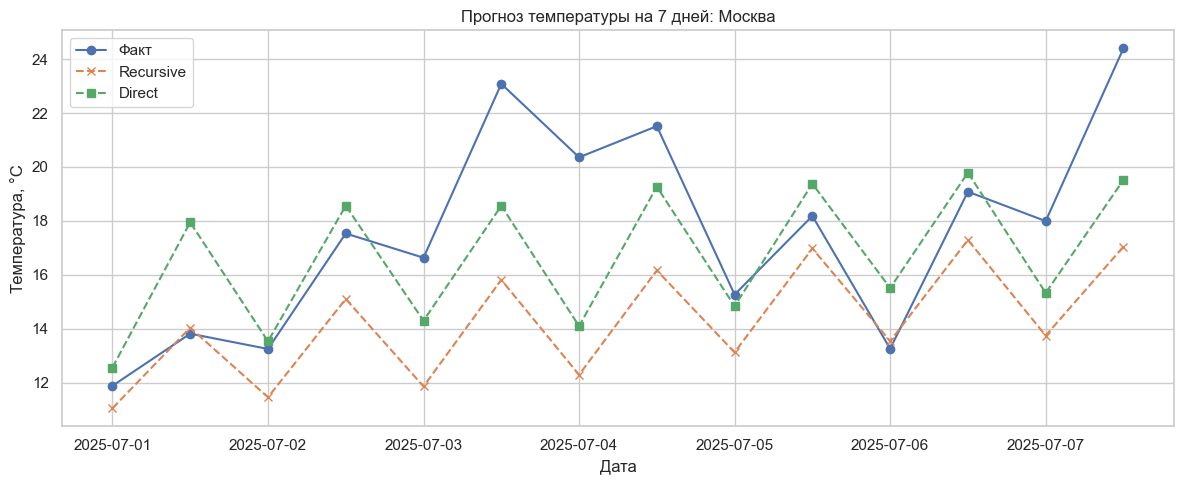

,strategy,MAE,WAPE,Directional Accuracy
1,Direct,2.4008,13.6488,100.0
0,Recursive,3.4113,19.3937,100.0


In [13]:
city_for_forecast = "Москва"
city_data = df_ml[df_ml["city"] == city_for_forecast].sort_values("ds").reset_index(drop=True)
start_time = city_data[city_data["ds"] >= TEST_START]["ds"].iloc[0]
future_data = city_data[city_data["ds"] >= start_time].head(HORIZON).copy()
actual = future_data[TARGET].values
forecast_dates = future_data["ds"].values

#Обучаем рекурсивно
history = city_data[city_data["ds"] < start_time][TARGET].tolist()
recursive_preds = []

for step in range(HORIZON):
    row = future_data.iloc[[step]].copy()
    row_encoded = pd.get_dummies(row, columns=["city"], prefix="city")
    row_encoded = row_encoded.reindex(columns=feature_cols, fill_value=0).astype(float)

    # Вместо реальных будущих лагов подставляем уже предсказанные моделью данные+реальные признаки
    row_encoded["temp_lag_1"] = history[-1]
    row_encoded["temp_lag_2"] = history[-2]
    row_encoded["temp_lag_14"] = history[-14]
    row_encoded["temp_roll_mean_14"] = np.mean(history[-14:])

    pred = best_xgb.predict(row_encoded)[0]
    recursive_preds.append(pred)
    history.append(pred)

#Прямая стратегия
origin_row = city_data[city_data["ds"] < start_time].tail(1).copy()
origin_encoded = pd.get_dummies(origin_row, columns=["city"], prefix="city")
origin_encoded = origin_encoded.reindex(columns=feature_cols, fill_value=0).astype(float)

direct_preds = []

for h in range(1, HORIZON + 1):
    direct_df = df_ml.copy()
    direct_df["target_h"] = direct_df.groupby("city")[TARGET].shift(-h)
    direct_df["target_time"] = direct_df.groupby("city")["ds"].shift(-h)
    direct_df = direct_df.dropna(subset=["target_h", "target_time"])

    direct_encoded = pd.get_dummies(direct_df, columns=["city"], prefix="city")
    X_direct = direct_encoded.reindex(columns=feature_cols, fill_value=0).astype(float)
    y_direct = direct_encoded["target_h"]

    train_direct_mask = direct_encoded["target_time"] < TEST_START

    model_h = xgb.XGBRegressor(
        **study_xgb.best_params,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        tree_method="hist",
    )
    model_h.fit(X_direct[train_direct_mask], y_direct[train_direct_mask])

    pred_h = model_h.predict(origin_encoded)[0]
    direct_preds.append(pred_h)

strategy_rows = []
for strategy_name, preds in {
    "Recursive": recursive_preds,
    "Direct": direct_preds,
}.items():
    strategy_metrics = calc_metrics(actual, preds, [city_for_forecast] * len(actual))
    strategy_rows.append({
        "strategy": strategy_name,
        "MAE": strategy_metrics["MAE"],
        "WAPE": strategy_metrics["WAPE"],
        "Directional Accuracy": strategy_metrics["Directional Accuracy"],
    })

strategy_comparison = pd.DataFrame(strategy_rows).sort_values("MAE")

plt.figure(figsize=(12, 5))
plt.plot(forecast_dates, actual, marker="o", label="Факт")
plt.plot(forecast_dates, recursive_preds, marker="x", linestyle="--", label="Recursive")
plt.plot(forecast_dates, direct_preds, marker="s", linestyle="--", label="Direct")
plt.title(f"Прогноз температуры на 7 дней: {city_for_forecast}")
plt.xlabel("Дата")
plt.ylabel("Температура, C")
plt.legend()
plt.tight_layout()
plt.show()

display(strategy_comparison.round(4))


## 9. Итоговый вывод

Лучшей моделью на тесте стала XGBoost. Ее ошибка MAE равна 1.42 °C, а WAPE равен 9.93%. Это значит, что модель в среднем ошибается примерно на несколько градусов.

Для прогноза на 7 дней лучше сработала прямая стратегия: MAE = 2.40 °C, WAPE = 13.65%. Рекурсивная стратегия проще, но она может копить ошибку, потому что каждый следующий шаг использует предыдущий прогноз.

Агрегация до 12 часов помогла уменьшить шум и оставить понятный смысл: день и ночь. Лаги дали модели информацию о прошлой температуре, а хронологическое разделение Train-Val-Test защитило работу от утечки будущего.

MAPE для температуры не всегда удобен, потому что около 0 °C проценты могут становиться слишком большими. Поэтому в итоговом сравнении лучше опираться на MAE и WAPE.
